In [ ]:
from expectation.seqtest.sequential_e_testing import SequentialTesting, TestType
from expectation.utils.helper_functions import plot_sequential_test_plotly

import numpy as np

import matplotlib.pyplot as plt

# EXPERIMENTAL: testing conformal e-values and conformal CUSUM

In [2]:
from expectation.conformal.conformal import ConformalEValue, ConformalEPseudomartingale, TruncatedEPseudomartingale

In [3]:
def generate_change_point_data(n_pre: int = 1000, 
                             n_post: int = 1000, 
                             pre_mean: float = 0.0,
                             post_mean: float = 0.5,
                             std: float = 1.0):
    pre_data = np.random.normal(pre_mean, std, n_pre)
    post_data = np.random.normal(post_mean, std, n_post)
    data = np.concatenate([pre_data, post_data])
    change_point = n_pre
    return data, change_point

# Example 1: Basic E-Value Computation
def example_basic_e_values(n_pre: int = 1000, n_post: int = 1000):
    print("\nExample 1: Basic E-Value Computation")
    
    # Generate some data
    np.random.seed(42)
    data, change_point = generate_change_point_data(n_pre=n_pre, n_post=n_post)
    
    # Initialize conformal e-value calculator
    e_calculator = ConformalEValue()
    
    # Process data in batches
    batch_size = 10
    e_values = []
    
    for i in range(0, len(data), batch_size):
        batch = data[i:i+batch_size]
        e_value = e_calculator.update(batch)
        e_values.append(e_value)
        print(f"Batch {i//batch_size + 1} e-value: {e_value:.4f}")
    
    return np.array(e_values)

# Example 2: E-Pseudomartingale with Change Point Detection
def example_change_detection():
    print("\nExample 2: Change Point Detection")
    
    # Generate data with change point
    data, change_point = generate_change_point_data()
    
    # Initialize e-value calculator and pseudomartingale
    e_calculator = ConformalEValue()
    e_martingale = ConformalEPseudomartingale()
    
    # Process data and track capital
    threshold = 20  # Detection threshold
    detection_time = None
    capitals = []
    
    for i in range(0, len(data), 10):
        # Get batch and compute e-value
        batch = data[i:i+10]
        e_value = e_calculator.update(batch)
        
        # Update martingale
        capital, max_capital = e_martingale.update(e_value)
        capitals.append(capital)
        
        # Check for change point
        if capital >= threshold and detection_time is None:
            detection_time = i
            print(f"Change detected at step {i} (true change point: {change_point})")
    
    return np.array(capitals), detection_time, change_point

# Example 3: Truncated Martingale Comparison
def example_truncated_comparison(n: int = 1000):
    print("\nExample 3: Truncated vs Regular Martingale")
    
    # Generate challenging data
    data = np.random.normal(0, 1, n)  # Add some outliers
    data[50:70] += 3  # Create a temporary shift
    
    # Initialize both types
    e_calculator = ConformalEValue()
    regular_mart = ConformalEPseudomartingale()
    truncated_mart = TruncatedEPseudomartingale(min_capital=0.1)
    
    regular_caps = []
    truncated_caps = []
    
    # Process data
    for i in range(0, len(data), 5):
        batch = data[i:i+5]
        e_value = e_calculator.update(batch)
        
        reg_cap, _ = regular_mart.update(e_value)
        trunc_cap, _ = truncated_mart.update(e_value)
        
        regular_caps.append(reg_cap)
        truncated_caps.append(trunc_cap)
    
    return np.array(regular_caps), np.array(truncated_caps)

def plot_results(e_values, capitals, detection_time, change_point, 
                regular_caps, truncated_caps):
    plt.figure(figsize=(15, 10))
    
    # Plot 1: E-values
    plt.subplot(3, 1, 1)
    plt.plot(e_values, label='E-values')
    plt.title('Conformal E-values')
    plt.legend()
    plt.grid(True)
    
    # Plot 2: Change Detection
    plt.subplot(3, 1, 2)
    plt.plot(capitals, label='Martingale Capital')
    if detection_time is not None:
        plt.axvline(x=detection_time/10, color='r', linestyle='--', 
                   label='Detected Change')
    plt.axvline(x=change_point/10, color='g', linestyle='--', 
                label='True Change Point')
    plt.title('Change Point Detection')
    plt.legend()
    plt.grid(True)
    
    # Plot 3: Truncated Comparison
    plt.subplot(3, 1, 3)
    plt.plot(regular_caps, label='Regular')
    plt.plot(truncated_caps, label='Truncated')
    plt.title('Regular vs Truncated Martingale')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


Example 1: Basic E-Value Computation
Batch 1 e-value: 1.5926
Batch 2 e-value: 0.0560
Batch 3 e-value: 0.3031
Batch 4 e-value: 0.2615
Batch 5 e-value: 0.3208
Batch 6 e-value: 1.3874
Batch 7 e-value: 0.5114
Batch 8 e-value: 0.4426
Batch 9 e-value: 0.6540
Batch 10 e-value: 0.3146
Batch 11 e-value: 0.4077
Batch 12 e-value: 0.7213
Batch 13 e-value: 0.5333
Batch 14 e-value: 0.2217
Batch 15 e-value: 0.3795
Batch 16 e-value: 0.6994
Batch 17 e-value: 1.2826
Batch 18 e-value: 1.3377
Batch 19 e-value: 0.2322
Batch 20 e-value: 0.2557
Batch 21 e-value: 5.2358
Batch 22 e-value: 0.7129
Batch 23 e-value: 0.2915
Batch 24 e-value: 0.3623
Batch 25 e-value: 0.3591
Batch 26 e-value: 0.7568
Batch 27 e-value: 0.1193
Batch 28 e-value: 0.3705
Batch 29 e-value: 0.5410
Batch 30 e-value: 0.6100
Batch 31 e-value: 0.4816
Batch 32 e-value: 1.5244
Batch 33 e-value: 0.8197
Batch 34 e-value: 0.2303
Batch 35 e-value: 0.1488
Batch 36 e-value: 0.4254
Batch 37 e-value: 0.6690
Batch 38 e-value: 5.6348
Batch 39 e-value: 0.2

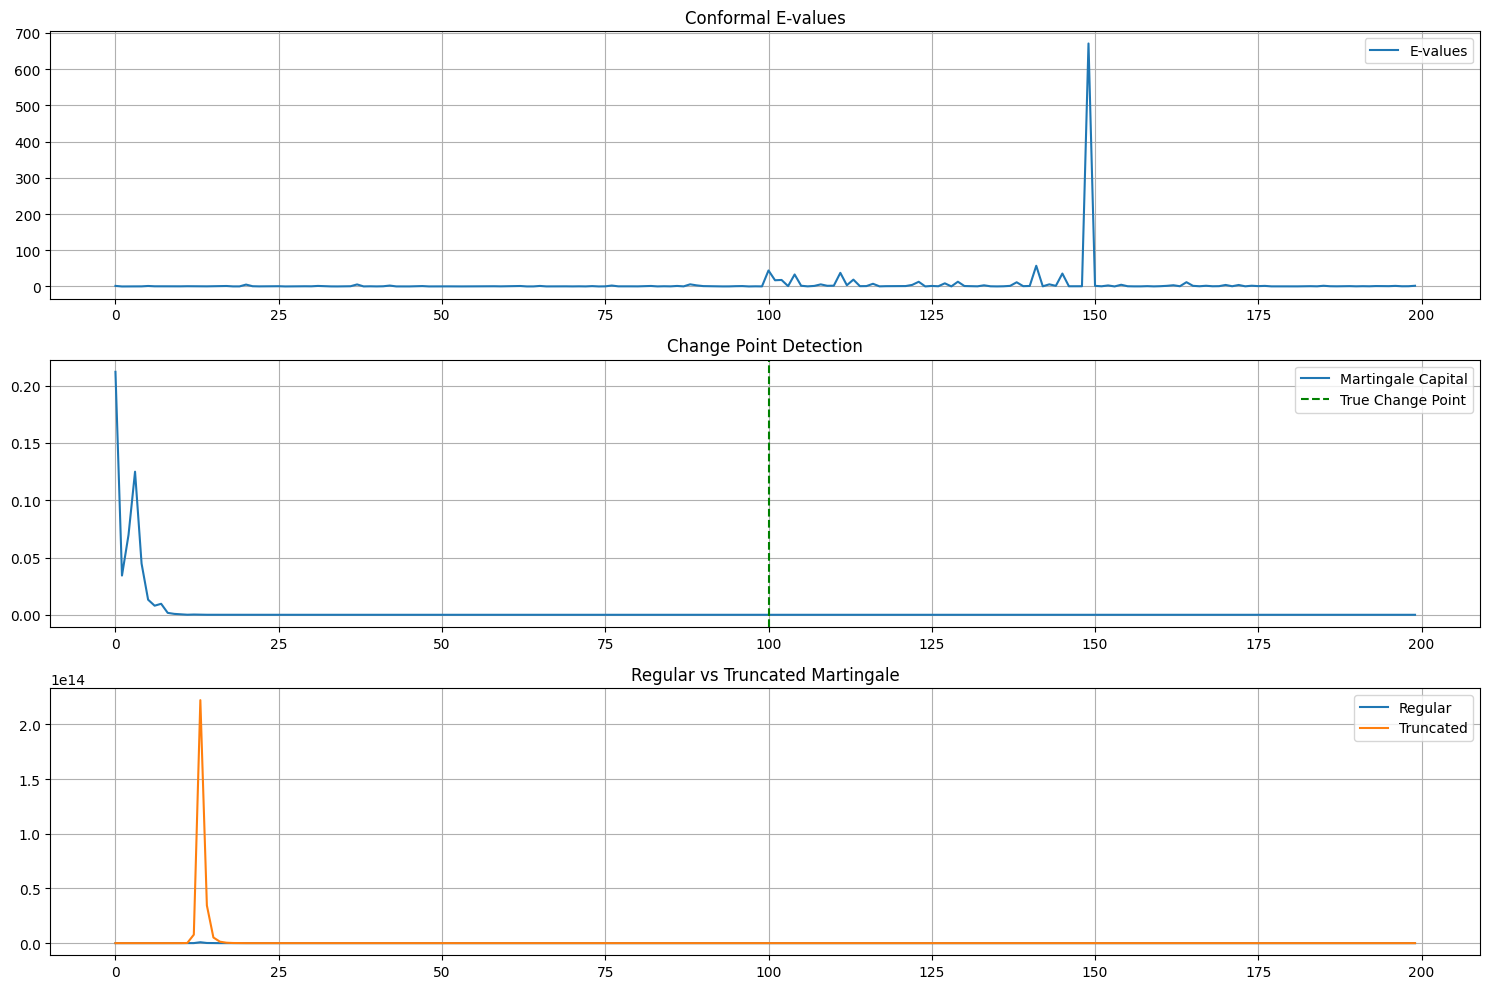

In [4]:
# Run all examples
e_values = example_basic_e_values()
capitals, detection_time, change_point = example_change_detection()
regular_caps, truncated_caps = example_truncated_comparison()

# Plot results
plot_results(e_values, capitals, detection_time, change_point, 
            regular_caps, truncated_caps)

In [5]:
from expectation.conformal.cusum import ConformalCUSUM, EfficiencyAnalyzer

def run_cusum_comparison():
    # Generate data with change point
    np.random.seed(42)
    n_pre, n_post = 1000, 1000
    pre_data = np.random.normal(0, 1, n_pre)
    post_data = np.random.normal(0.5, 1, n_post)
    data = np.concatenate([pre_data, post_data])
    
    # Initialize detectors
    standard_cusum = ConformalCUSUM(threshold=20.0, use_sr=False)
    sr_cusum = ConformalCUSUM(threshold=20.0, use_sr=True)
    
    # Process data
    standard_stats = []
    sr_stats = []
    
    for x in data:
        # Compute e-value (simplified for example)
        e_value = np.exp(-0.5 * (x - 0.5)**2 + 0.5 * x**2)
        
        # Update detectors
        standard_result = standard_cusum.update(e_value)
        sr_result = sr_cusum.update(e_value)
        
        standard_stats.append(standard_result.statistic)
        sr_stats.append(sr_result.statistic)
    
    # Plot results
    plt.figure(figsize=(12, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(standard_stats, label='Standard CUSUM')
    plt.axvline(x=n_pre, color='r', linestyle='--', label='Change Point')
    for alarm in standard_result.alarms:
        plt.axvline(x=alarm, color='g', linestyle=':', alpha=0.5)
    plt.title('Standard CUSUM')
    plt.legend()
    
    plt.subplot(2, 1, 2)
    plt.plot(sr_stats, label='SR-CUSUM')
    plt.axvline(x=n_pre, color='r', linestyle='--', label='Change Point')
    for alarm in sr_result.alarms:
        plt.axvline(x=alarm, color='g', linestyle=':', alpha=0.5)
    plt.title('Shiryaev-Roberts CUSUM')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Analyze efficiency
    analyzer = EfficiencyAnalyzer()
    standard_metrics = analyzer.compute_efficiency_metrics(standard_cusum)
    sr_metrics = analyzer.compute_efficiency_metrics(sr_cusum)
    
    print("\nEfficiency Metrics:")
    print("\nStandard CUSUM:")
    for metric, value in standard_metrics.items():
        print(f"{metric}: {value:.4f}")
        
    print("\nShiryaev-Roberts CUSUM:")
    for metric, value in sr_metrics.items():
        print(f"{metric}: {value:.4f}")

## Below seems to confirm Vovk's Example 7

"

Example 7. Consider the vacuous admissible conformal e-predictor identically equal to 1. <br>

The CUSUM procedure based on it will never raise alarms, while the Shiryaev–Roberts e-procedure will raise alarms every ⌈c⌉th step, <br>
thereby fully exploiting (for an integer c) the leeway permitted by our target property of validity (8). <br>
This example shows one feature of the Shiryaev–Roberts procedure (shared by the reverse Shiryaev–Roberts procedure) that can be considered its <br> disadvantage: while the CUSUM procedure raises an alarm when it has genuine evidence for disorder, the Shiryaev–Roberts procedure may raise an alarm <br> simply because it is allowed to do so by a given constraint; we might not have any evidence for disorder

"

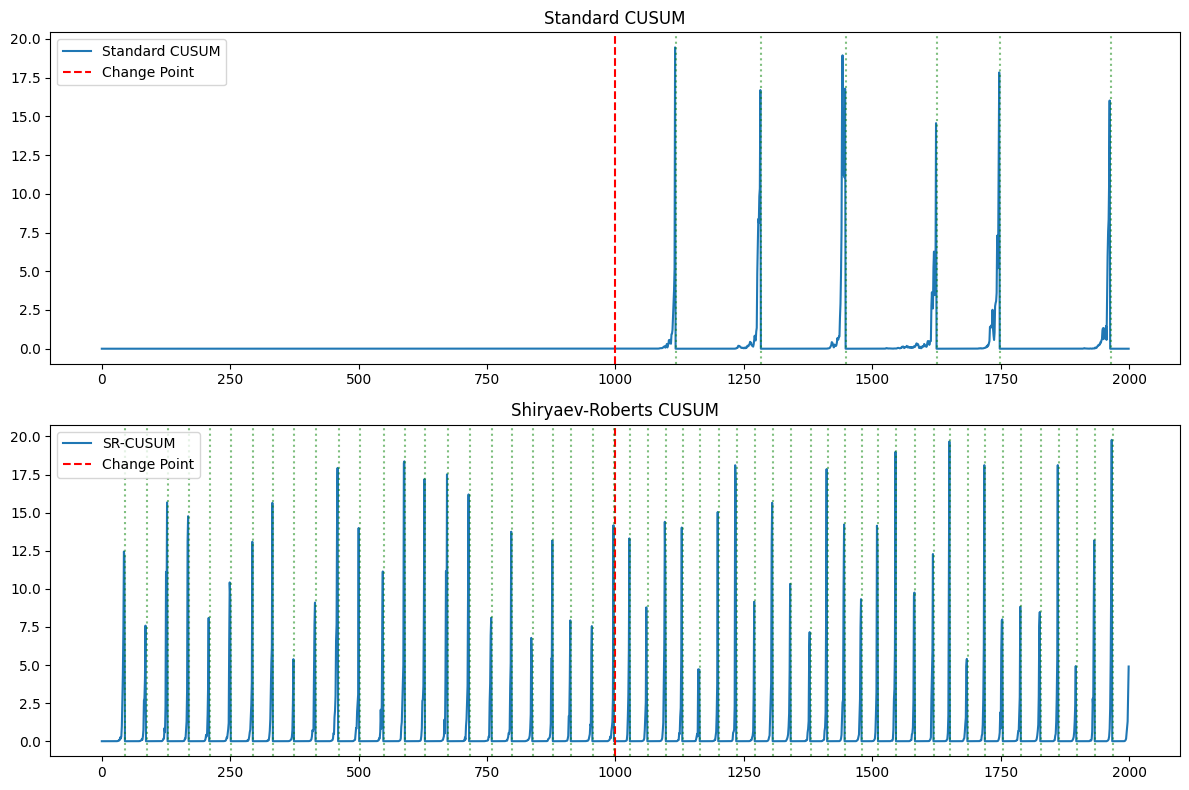


Efficiency Metrics:

Standard CUSUM:
mean_detection_delay: 198.3500
detection_delay_std: 59.4250
false_alarm_rate: 0.0000
mean_decay_rate: -0.0000
decay_rate_std: 0.0006

Shiryaev-Roberts CUSUM:
mean_detection_delay: 16.4300
detection_delay_std: 11.0619
false_alarm_rate: 974.6100
mean_decay_rate: 0.0001
decay_rate_std: 0.0007


In [6]:
run_cusum_comparison()

In [7]:
from expectation.seqtest.sequential_e_testing import (
    SequentialTesting, TestType, AlternativeType
)
from expectation.modules.hypothesistesting import EValueConfig

In [8]:
def run_integrated_test():
    # Generate test data with a change point
    np.random.seed(42)
    n_pre, n_post = 1000, 1000
    change_point = n_pre
    
    pre_data = np.random.normal(0, 1, n_pre)
    post_data = np.random.normal(0.5, 1, n_post)
    data = np.concatenate([pre_data, post_data])
    
    # Initialize detectors
    # 1. Sequential test for e-values
    seq_test = SequentialTesting(
        test_type="mean",
        null_value=0.0,
        alternative="greater",
        config=EValueConfig(significance_level=0.05)
    )
    
    # 2. CUSUM detectors (standard and SR)
    standard_cusum = ConformalCUSUM(threshold=20.0, use_sr=False)
    sr_cusum = ConformalCUSUM(threshold=20.0, use_sr=True)
    
    # Storage for results
    e_values = []
    standard_stats = []
    sr_stats = []
    cum_e_values = []
    
    # Process data in batches
    batch_size = 10
    for i in range(0, len(data), batch_size):
        batch = data[i:i+batch_size]
        
        # Get e-value from sequential test
        result = seq_test.update(batch)
        e_value = result.e_value
        e_values.append(e_value)
        cum_e_values.append(result.e_process.cumulative_value)
        
        # Update both CUSUM detectors
        standard_result = standard_cusum.update(e_value)
        sr_result = sr_cusum.update(e_value)
        
        standard_stats.append(standard_result.statistic)
        sr_stats.append(sr_result.statistic)
    
    # Plot results
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: Individual e-values
    steps = np.arange(len(e_values))
    ax1.plot(steps, e_values, label='E-values')
    ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax1.axvline(x=change_point/batch_size, color='r', 
                linestyle='--', label='Change Point')
    ax1.set_title('Sequential Test E-values')
    ax1.set_yscale('log')
    ax1.grid(True)
    ax1.legend()
    
    # Plot 2: Cumulative e-values
    ax2.plot(steps, cum_e_values, label='Cumulative E-values')
    ax2.axhline(y=1/0.05, color='r', linestyle='--', 
                label='Rejection Threshold (α=0.05)')
    ax2.axvline(x=change_point/batch_size, color='r', linestyle='--')
    ax2.set_title('Cumulative E-process')
    ax2.set_yscale('log')
    ax2.grid(True)
    ax2.legend()
    
    # Plot 3: Standard CUSUM
    ax3.plot(steps, standard_stats, label='Standard CUSUM')
    ax3.axhline(y=standard_cusum.threshold, color='r', 
                linestyle='--', label='Threshold')
    ax3.axvline(x=change_point/batch_size, color='r', linestyle='--')
    for alarm in standard_result.alarms:
        ax3.axvline(x=alarm/batch_size, color='g', 
                   linestyle=':', alpha=0.5, label='Alarm')
    ax3.set_title('Standard CUSUM Monitoring')
    ax3.set_yscale('log')
    ax3.grid(True)
    ax3.legend()
    
    # Plot 4: SR-CUSUM
    ax4.plot(steps, sr_stats, label='SR-CUSUM')
    ax4.axhline(y=sr_cusum.threshold, color='r', 
                linestyle='--', label='Threshold')
    ax4.axvline(x=change_point/batch_size, color='r', linestyle='--')
    for alarm in sr_result.alarms:
        ax4.axvline(x=alarm/batch_size, color='g', 
                   linestyle=':', alpha=0.5, label='Alarm')
    ax4.set_title('Shiryaev-Roberts CUSUM Monitoring')
    ax4.set_yscale('log')
    ax4.grid(True)
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nMonitoring Summary:")
    print(f"Number of batches processed: {len(e_values)}")
    print("\nSequential Test:")
    print(f"Final e-process value: {cum_e_values[-1]:.2f}")
    print(f"Reject null hypothesis: {result.reject_null}")
    
    print("\nStandard CUSUM:")
    print(f"Number of alarms: {standard_result.n_alarms}")
    if standard_result.alarms:
        print(f"First alarm at batch: {standard_result.alarms[0]/batch_size:.0f}")
    
    print("\nShiryaev-Roberts CUSUM:")
    print(f"Number of alarms: {sr_result.n_alarms}")
    if sr_result.alarms:
        print(f"First alarm at batch: {sr_result.alarms[0]/batch_size:.0f}")


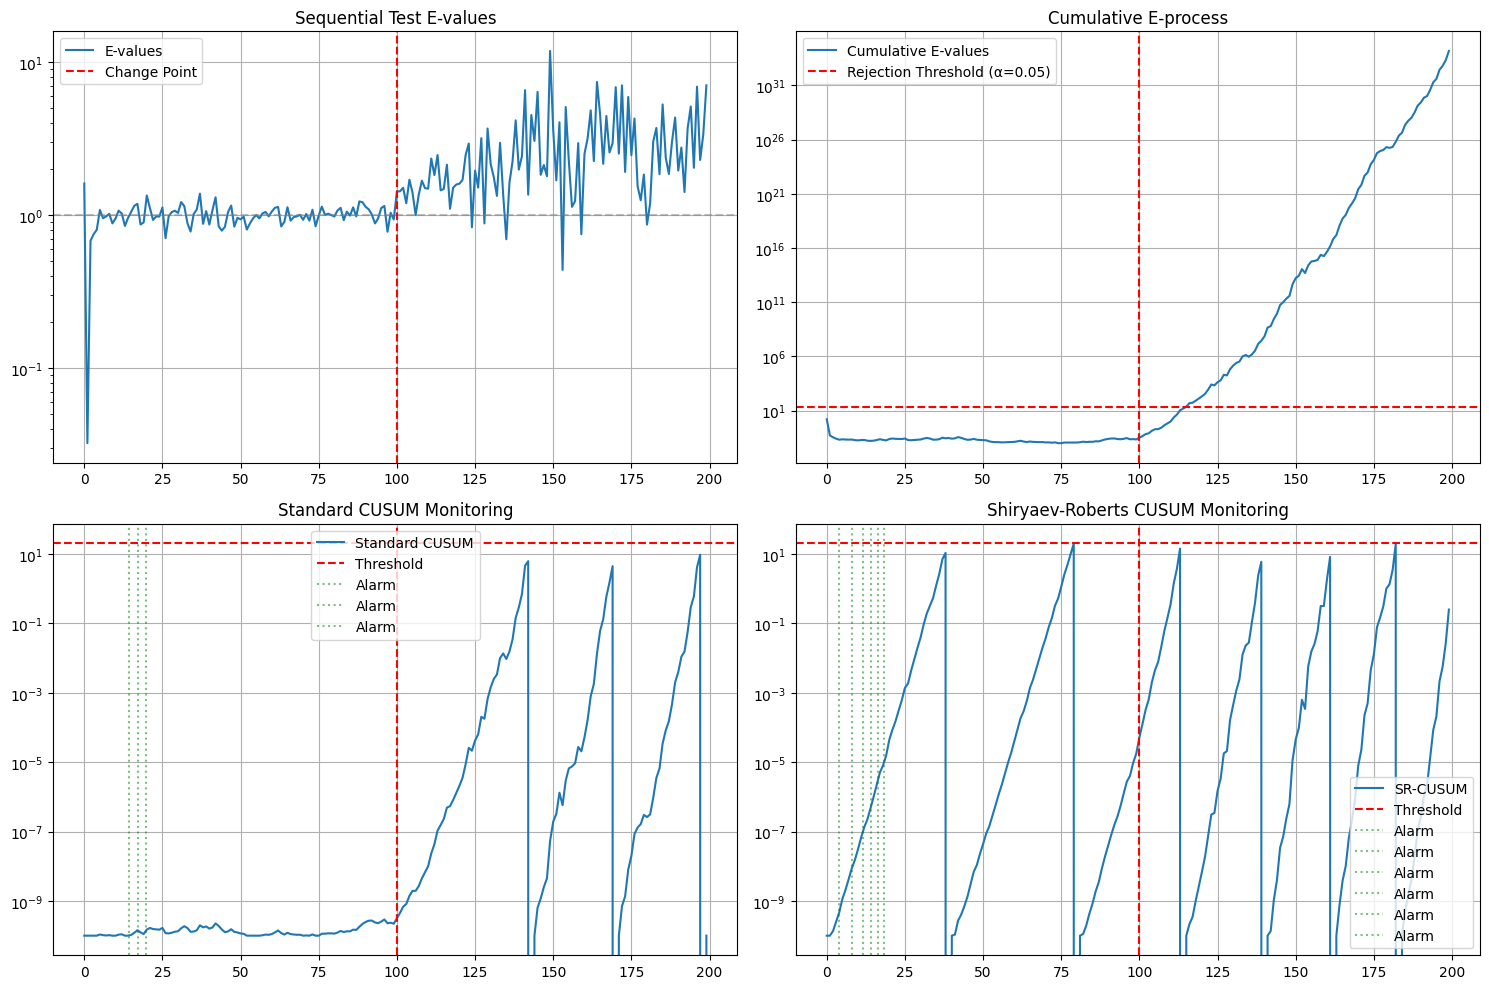


Monitoring Summary:
Number of batches processed: 200

Sequential Test:
Final e-process value: 15047858986958223174923584066813952.00
Reject null hypothesis: True

Standard CUSUM:
Number of alarms: 3
First alarm at batch: 14

Shiryaev-Roberts CUSUM:
Number of alarms: 6
First alarm at batch: 4


In [9]:
run_integrated_test()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from expectation.seqtest.sequential_e_testing import (
    SequentialTesting, TestType, AlternativeType
)
from expectation.modules.hypothesistesting import EValueConfig

def run_integrated_conformal_test():
    # Generate test data with a change point
    np.random.seed(42)
    n_pre, n_post = 1000, 1000
    change_point = n_pre
    
    pre_data = np.random.normal(0, 1, n_pre)
    post_data = np.random.normal(0.5, 1, n_post)
    data = np.concatenate([pre_data, post_data])
    
    # Initialize all components
    # 1. ConformalEValue calculator
    conformal_e = ConformalEValue(allow_infinite=False)
    
    # 2. Sequential test for comparison
    seq_test = SequentialTesting(
        test_type="mean",
        null_value=0.0,
        alternative="greater",
        config=EValueConfig(significance_level=0.05)
    )
    
    # 3. CUSUM detectors
    standard_cusum = ConformalCUSUM(threshold=20.0, use_sr=False)
    sr_cusum = ConformalCUSUM(threshold=20.0, use_sr=True)
    
    # Storage for results
    conformal_e_values = []
    sequential_e_values = []
    standard_stats = []
    sr_stats = []
    conformal_cum_e_values = []
    sequential_cum_e_values = []
    
    # Process data in batches
    batch_size = 10
    running_product = 1.0
    
    for i in range(0, len(data), batch_size):
        batch = data[i:i+batch_size]
        
        # Get e-values from both methods
        conformal_e_value = conformal_e.update(batch)
        seq_result = seq_test.update(batch)
        
        # Store e-values
        conformal_e_values.append(conformal_e_value)
        sequential_e_values.append(seq_result.e_value)
        
        # Update running products
        running_product *= conformal_e_value
        conformal_cum_e_values.append(running_product)
        sequential_cum_e_values.append(seq_result.e_process.cumulative_value)
        
        # Update CUSUM with conformal e-values
        standard_result = standard_cusum.update(conformal_e_value)
        sr_result = sr_cusum.update(conformal_e_value)
        
        standard_stats.append(standard_result.statistic)
        sr_stats.append(sr_result.statistic)
    
    # Plotting
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    steps = np.arange(len(conformal_e_values))
    
    # Plot 1: Individual e-values comparison
    ax1.plot(steps, conformal_e_values, label='Conformal E-values')
    ax1.plot(steps, sequential_e_values, label='Sequential E-values', alpha=0.7)
    ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax1.axvline(x=change_point/batch_size, color='r', 
                linestyle='--', label='Change Point')
    ax1.set_title('E-values Comparison')
    ax1.set_yscale('log')
    ax1.grid(True)
    ax1.legend()
    
    # Plot 2: Cumulative e-values comparison
    ax2.plot(steps, conformal_cum_e_values, label='Conformal Cumulative')
    ax2.plot(steps, sequential_cum_e_values, label='Sequential Cumulative', alpha=0.7)
    ax2.axhline(y=1/0.05, color='r', linestyle='--', 
                label='Rejection Threshold (α=0.05)')
    ax2.axvline(x=change_point/batch_size, color='r', linestyle='--')
    ax2.set_title('Cumulative E-processes')
    ax2.set_yscale('log')
    ax2.grid(True)
    ax2.legend()
    
    # Plot 3: Standard CUSUM with conformal e-values
    ax3.plot(steps, standard_stats, label='Standard CUSUM')
    ax3.axhline(y=standard_cusum.threshold, color='r', 
                linestyle='--', label='Threshold')
    ax3.axvline(x=change_point/batch_size, color='r', linestyle='--')
    for alarm in standard_result.alarms:
        ax3.axvline(x=alarm/batch_size, color='g', 
                   linestyle=':', alpha=0.5, label='Alarm')
    ax3.set_title('Standard CUSUM (Conformal E-values)')
    ax3.set_yscale('log')
    ax3.grid(True)
    ax3.legend()
    
    # Plot 4: SR-CUSUM with conformal e-values
    ax4.plot(steps, sr_stats, label='SR-CUSUM')
    ax4.axhline(y=sr_cusum.threshold, color='r', 
                linestyle='--', label='Threshold')
    ax4.axvline(x=change_point/batch_size, color='r', linestyle='--')
    for alarm in sr_result.alarms:
        ax4.axvline(x=alarm/batch_size, color='g', 
                   linestyle=':', alpha=0.5, label='Alarm')
    ax4.set_title('SR-CUSUM (Conformal E-values)')
    ax4.set_yscale('log')
    ax4.grid(True)
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nMonitoring Summary:")
    print(f"Number of batches processed: {len(conformal_e_values)}")
    print("\nConformal E-values:")
    print(f"Final cumulative value: {conformal_cum_e_values[-1]:.2f}")
    print(f"Reject null hypothesis: {conformal_cum_e_values[-1] >= 1/0.05}")
    print("\nSequential Test:")
    print(f"Final e-process value: {sequential_cum_e_values[-1]:.2f}")
    print(f"Reject null hypothesis: {seq_result.reject_null}")
    print("\nStandard CUSUM (Conformal):")
    print(f"Number of alarms: {standard_result.n_alarms}")
    if standard_result.alarms:
        print(f"First alarm at batch: {standard_result.alarms[0]/batch_size:.0f}")
    print("\nShiryaev-Roberts CUSUM (Conformal):")
    print(f"Number of alarms: {sr_result.n_alarms}")
    if sr_result.alarms:
        print(f"First alarm at batch: {sr_result.alarms[0]/batch_size:.0f}")



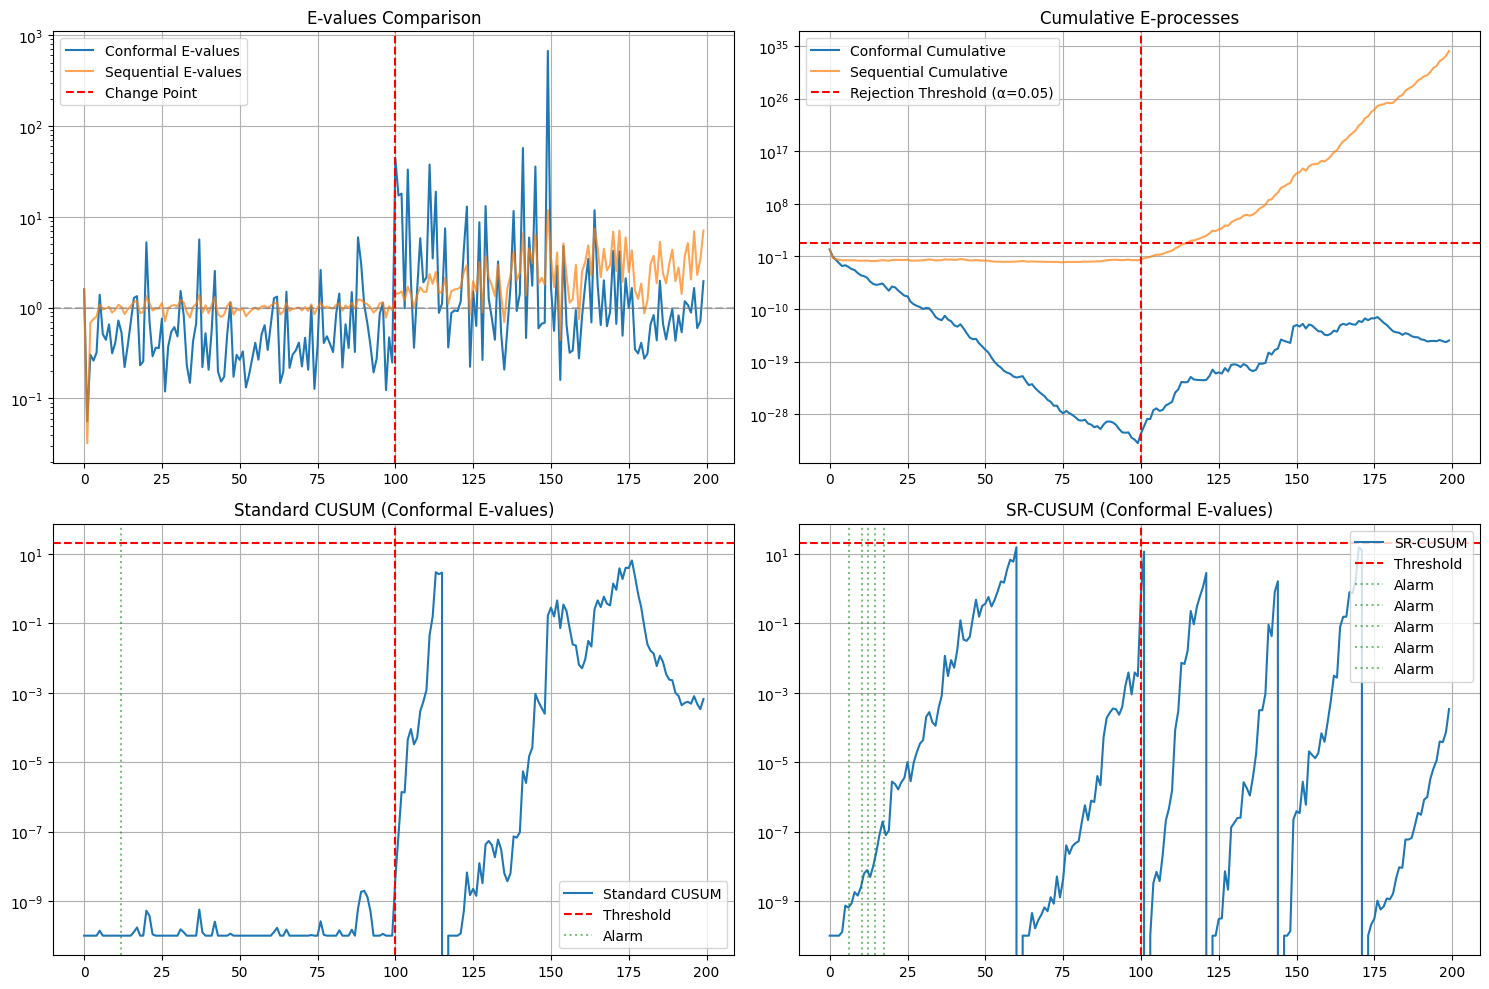


Monitoring Summary:
Number of batches processed: 200

Conformal E-values:
Final cumulative value: 0.00
Reject null hypothesis: False

Sequential Test:
Final e-process value: 15047858986958223174923584066813952.00
Reject null hypothesis: True

Standard CUSUM (Conformal):
Number of alarms: 1
First alarm at batch: 12

Shiryaev-Roberts CUSUM (Conformal):
Number of alarms: 5
First alarm at batch: 6


In [11]:

run_integrated_conformal_test()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from expectation.seqtest.sequential_e_testing import (
    SequentialTesting, TestType, AlternativeType
)
from expectation.modules.hypothesistesting import EValueConfig
from expectation.conformal.adaptivethreshold import AdaptiveThresholdHandler

def run_integrated_conformal_test():
    # Generate test data with a change point
    np.random.seed(42)
    n_pre, n_post = 1000, 1000
    change_point = n_pre
    
    pre_data = np.random.normal(0, 1, n_pre)
    post_data = np.random.normal(1.0, 1, n_post)
    data = np.concatenate([pre_data, post_data])
    
    # Initialize all components
    # 1. ConformalEValue calculator
    conformal_e = ConformalEValue(allow_infinite=False)
    
    # 2. Sequential test for comparison
    seq_test = SequentialTesting(
        test_type="mean",
        null_value=0.0,
        alternative="greater",
        config=EValueConfig(significance_level=0.05)
    )
    
    # 3. CUSUM detectors (standard and adaptive)
    initial_threshold = 20.0
    standard_cusum = ConformalCUSUM(threshold=initial_threshold, use_sr=False)
    adaptive_threshold_handler = AdaptiveThresholdHandler(target_false_alarm_rate=0.05, learning_rate=0.01)
    adaptive_cusum = ConformalCUSUM(threshold=initial_threshold, use_sr=False)

    # Storage for results
    conformal_e_values = []
    sequential_e_values = []
    standard_stats = []
    adaptive_stats = []
    conformal_cum_e_values = []
    sequential_cum_e_values = []
    adaptive_thresholds = []  # Track the threshold evolution
    
    # Process data in batches
    batch_size = 10
    running_product = 1.0

    prev_adaptive_alarms = 0

    for i in range(0, len(data), batch_size):
        batch = data[i:i+batch_size]
        
        # Get e-values from both methods
        conformal_e_value = conformal_e.update(batch)
        seq_result = seq_test.update(batch)
        
        # Store e-values
        conformal_e_values.append(conformal_e_value)
        sequential_e_values.append(seq_result.e_value)
        
        # Update running products
        running_product *= conformal_e_value
        conformal_cum_e_values.append(running_product)
        sequential_cum_e_values.append(seq_result.e_process.cumulative_value)
        
        # Update Standard CUSUM with conformal e-values
        standard_result = standard_cusum.update(conformal_e_value)
        standard_stats.append(standard_result.statistic)
        
        # Update Adaptive CUSUM with conformal e-values
        adaptive_result = adaptive_cusum.update(conformal_e_value)
        adaptive_stats.append(adaptive_result.statistic)
        
        # Check if a new alarm has occurred in the adaptive CUSUM
        if adaptive_result.n_alarms > prev_adaptive_alarms:
            # A new alarm has occurred
            last_alarm_time = adaptive_result.alarms[-1]  # Time index of the last alarm
            data_index = last_alarm_time * batch_size  # Convert batch index to data index
            if data_index < change_point:
                # Alarm occurred before change point: false alarm
                adaptive_threshold_handler.record_alarm(is_false_alarm=True)
            else:
                # Alarm occurred after change point: true alarm
                adaptive_threshold_handler.record_alarm(is_false_alarm=False)
            # Update the previous number of alarms
            prev_adaptive_alarms = adaptive_result.n_alarms
            
            # Update adaptive threshold based on current alarms
            current_false_alarm_rate = adaptive_threshold_handler.get_current_rate()
            new_threshold = adaptive_threshold_handler.update(current_false_alarm_rate)
            adaptive_cusum.threshold = new_threshold
            adaptive_thresholds.append(new_threshold)
            print(f"Current false alarm rate: {current_false_alarm_rate:.4f}")
            print(f"New adaptive threshold: {new_threshold:.4f}")
        else:
            # Append the current threshold to keep the list lengths consistent
            adaptive_thresholds.append(adaptive_cusum.threshold)

    # Plotting
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    steps = np.arange(len(conformal_e_values))
    
    # Plot 1: Individual e-values comparison
    ax1.plot(steps, conformal_e_values, label='Conformal E-values')
    ax1.plot(steps, sequential_e_values, label='Sequential E-values', alpha=0.7)
    ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax1.axvline(x=change_point/batch_size, color='r', linestyle='--', label='Change Point')
    ax1.set_title('E-values Comparison')
    ax1.set_yscale('log')
    ax1.grid(True)
    ax1.legend()
    
    # Plot 2: Cumulative e-values comparison
    ax2.plot(steps, conformal_cum_e_values, label='Conformal Cumulative')
    ax2.plot(steps, sequential_cum_e_values, label='Sequential Cumulative', alpha=0.7)
    ax2.axhline(y=1/0.05, color='r', linestyle='--', label='Rejection Threshold (α=0.05)')
    ax2.axvline(x=change_point/batch_size, color='r', linestyle='--')
    ax2.set_title('Cumulative E-processes')
    ax2.set_yscale('log')
    ax2.grid(True)
    ax2.legend()
    
    # Plot 3: Standard vs Adaptive CUSUM (Conformal E-values)
    ax3.plot(steps, standard_stats, label='Standard CUSUM', alpha=0.7)
    ax3.plot(steps, adaptive_stats, label='Adaptive CUSUM', alpha=0.7)
    ax3.axhline(y=standard_cusum.threshold, color='r', linestyle='--', label='Fixed Threshold (Standard)')
    ax3.axvline(x=change_point/batch_size, color='r', linestyle='--')
    ax3.set_title('Standard vs Adaptive CUSUM (Conformal E-values)')
    ax3.set_yscale('log')
    ax3.grid(True)
    ax3.legend()
    
    # Plot 4: Adaptive Threshold Evolution
    ax4.plot(steps, adaptive_thresholds, label='Adaptive Threshold', color='purple')
    ax4.set_title('Adaptive Threshold Evolution')
    ax4.set_yscale('log')
    ax4.axvline(x=change_point/batch_size, color='r', linestyle='--', label='Change Point')
    ax4.grid(True)
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nMonitoring Summary:")
    print(f"Number of batches processed: {len(conformal_e_values)}")
    print("\nConformal E-values:")
    print(f"Final cumulative value: {conformal_cum_e_values[-1]:.2f}")
    print(f"Reject null hypothesis: {conformal_cum_e_values[-1] >= 1/0.05}")
    print("\nSequential Test:")
    print(f"Final e-process value: {sequential_cum_e_values[-1]:.2f}")
    print(f"Reject null hypothesis: {seq_result.reject_null}")
    print("\nStandard CUSUM (Conformal):")
    print(f"Number of alarms: {standard_result.n_alarms}")
    if standard_result.alarms:
        print(f"First alarm at batch: {standard_result.alarms[0]/batch_size:.0f}")
    print("\nAdaptive CUSUM (Conformal):")
    print(f"Number of alarms: {adaptive_result.n_alarms}")
    if adaptive_result.alarms:
        print(f"First alarm at batch: {adaptive_result.alarms[0]/batch_size:.0f}")





## Conformal CUSUM - maintaining validity but losing sensitivity

Below plots shows how regular e-values are highly sensitive to small changes but might produce high false alarm rate <br>
compared to conformal e-values. The conformal e-values, however, favors validity under the null and loses sensitivity to small changes <br>
so the false alarm rate is valid!

Current false alarm rate: 0.0000
New adaptive threshold: 9.9995
Current false alarm rate: 0.0000
New adaptive threshold: 9.9986
Current false alarm rate: 0.0000
New adaptive threshold: 9.9972
Current false alarm rate: 0.0000
New adaptive threshold: 9.9955
Current false alarm rate: 0.0000
New adaptive threshold: 9.9934
Current false alarm rate: 0.0000
New adaptive threshold: 9.9911


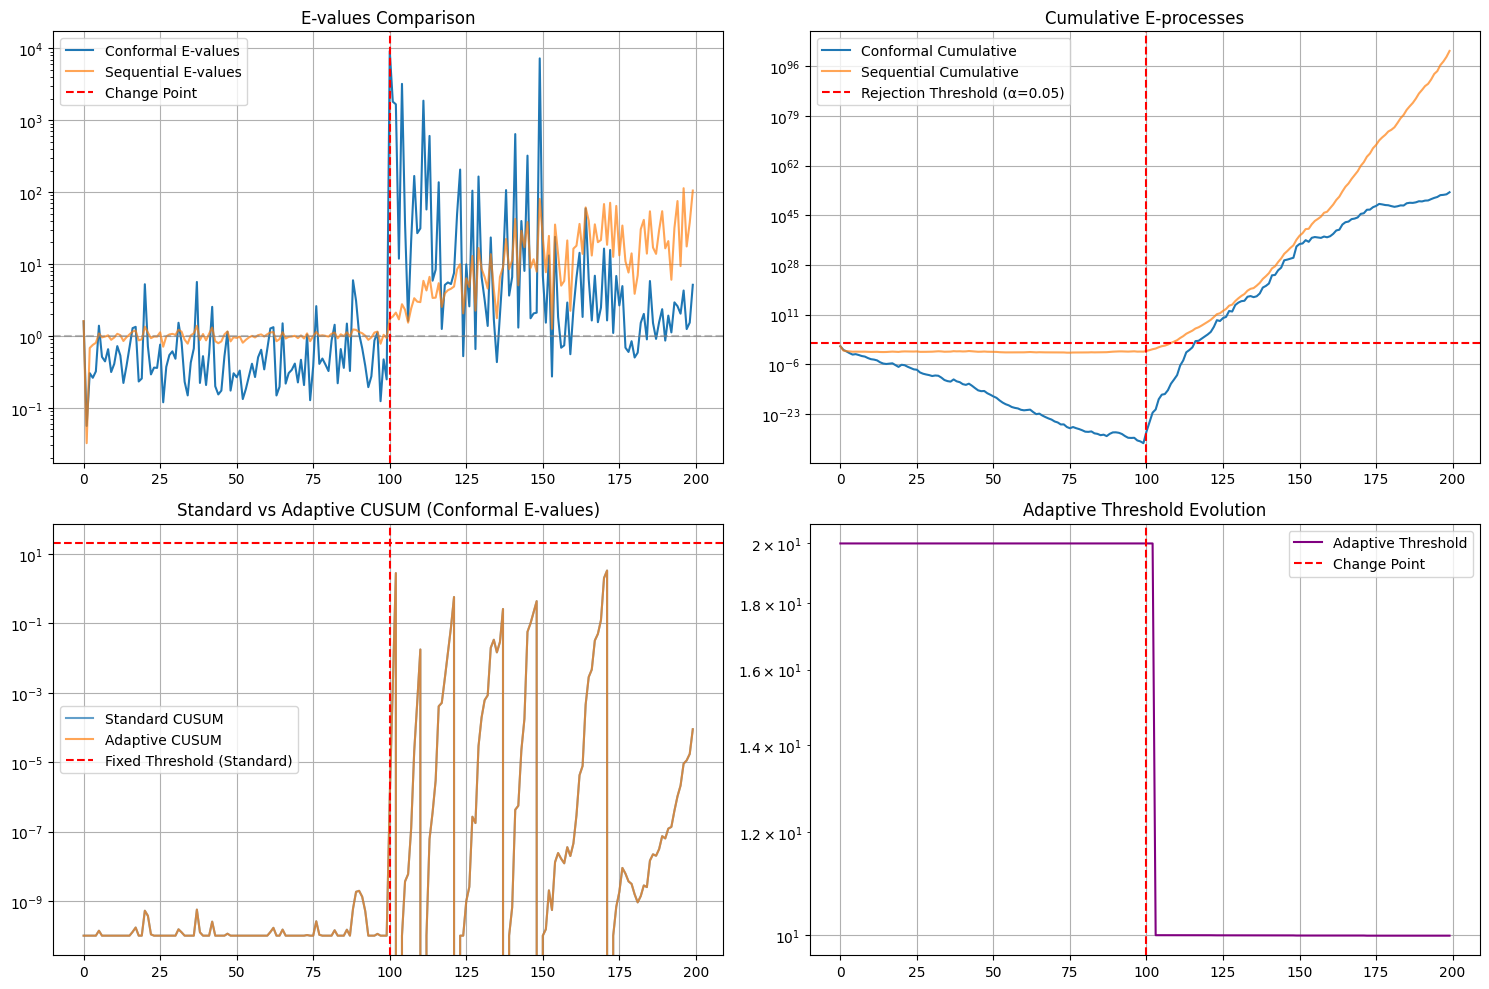


Monitoring Summary:
Number of batches processed: 200

Conformal E-values:
Final cumulative value: 77598621895874497465201024254888368395394008102207488.00
Reject null hypothesis: True

Sequential Test:
Final e-process value: 168739126169276815317875449795837993384261432557275036301249640276321843874708924794699839491293577216.00
Reject null hypothesis: True

Standard CUSUM (Conformal):
Number of alarms: 6
First alarm at batch: 10

Adaptive CUSUM (Conformal):
Number of alarms: 6
First alarm at batch: 10


In [13]:
run_integrated_conformal_test()